# 🛒 **Аналіз онлайн-ритейлера**
> Аналіз транзакцій інтернет-магазину для виявлення причин повернень товарів, сегментації клієнтів та пошуку можливостей для збільшення прибутку.


| Параметр | Значення |
|-----------|-----------|
| Інструменти | Python, Pandas, NumPy, Matplotlib, Seaborn, SQL (BigQuery) |
| Дані | ~540 000 транзакцій |
| Країни | 28 |
| Джерело | [ecommerce-data](https://www.kaggle.com/datasets/carrie1/ecommerce-data)


---

## 🎯 Бізнес контекст


 Компанія стикається зі зростанням кількості повернень товарів, що негативно впливає на прибутковість та операційні витрати.

---
##Метою аналізу

- Виявити причини повернень товарів
- Дослідити поведінку клієнтів
- Провести RFM-сегментацію
- Оцінити утримання клієнтів (Retention)
- Виявити можливості для збільшення виручки

---

## 💡 Очікувана бізнес-цінність

✅ Зменшення кількості повернень

✅ Покращення утримання клієнтів

✅ Оптимізація маркетингових кампаній

✅ Підвищення ефективності рекомендацій товарів

✅ Збільшення прибутковості бізнесу

---




---
##❓ 10 аналітичних питань
| # | Питання | Інструмент |
|---|---------|------------|
| 1 |Які товари мають найвищий відсоток повернень?|SQL|
| 2 |Чи впливає країна клієнта на рівень повернення?|SQL + Python|
| 3 |Скільки часу проходить між першою та другою покупкою клієнта?|SQL + Python|
| 4 |Які категорії товарів генерують найбільну виручку?|SQL + Python|
| 5 |Чи змінюється виручка по місяцям? Чи є сезон?|SQL + Python|
| 6 |Який середній чек?|SQL|
| 7 |Які товари купують частіше?|SQL + Python|
| 8 |Які товари найчастіше купують разом?|SQL|
| 9 |Який рівень утримання клієнтів по когортах?|SQL + Python|
| 10 |RFM аналіз - сегментація клієнтів за їхньою поведінкою|SQL + Python|
| 11 |Які RFM-сегменти генерують найбільшу частку виручки компанії?|Python|

---




##1. ⚙️ Налаштування середовища

In [9]:
#Стандартна бібліотека
import warnings

#Додаткові бібліотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Налаштування виконуються після всіх імпортів
warnings.filterwarnings("ignore")

#Єдиний стиль графіків на весь проєкт
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
})
sns.set_palette("tab10")

print("✅ Середовище готове")

✅ Середовище готове


---
## 2. 🗄️ Підключення до BigQuery

In [10]:
#Авторизація в Google Cloud
from google.colab import auth
auth.authenticate_user()
print("✅ Авторизовано")

✅ Авторизовано


In [11]:
#Підключення клієнта BigQuery
from google.cloud import bigquery

PROJECT_ID = "my-final-project-497412"
DATASET = "ecommerce_data"

client = bigquery.Client(project=PROJECT_ID)
print(f"✅ Підключено до проєкту: {PROJECT_ID}")

✅ Підключено до проєкту: my-final-project-497412


In [12]:
#Cлужбові функції для виклику BigQuery
def run_query(sql: str) -> pd.DataFrame:
    """Виконати SQL-запит у BigQuery і повернути DataFrame."""
    return client.query(sql).to_dataframe()


def full_table_name(table: str) -> str:
    """Сформувати повну назву таблиці у форматі `project.dataset.table`."""
    return f"`{PROJECT_ID}.{DATASET}.{table}`"


---
##3. 📂 Завантаження локальних даних та знайомство з ними

In [13]:
#Завантаження CSV-файлів локально для Python-аналізу
df = pd.read_csv("ecommerce_data.csv", encoding='cp1251')

print("✅ Дані завантажено локально")

✅ Дані завантажено локально


In [14]:
print("📊 Інформація про датасет")
print(f"Рядків:      {df.shape[0]:,}")
print(f"Колонок:     {df.shape[1]}")
print(f"Пам'ять:     {df.memory_usage(deep=True).sum()/1024/1024:.2f} MB")

📊 Інформація про датасет
Рядків:      541,909
Колонок:     8
Пам'ять:     173.12 MB


In [15]:
#Загальний вигляд даних
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


---
##4. 🧹Перевірка та очистка даних

In [16]:
#Перевірка на типи
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [17]:
#❗Для InvoiceDate і CustomerID змінюємо тип даних
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype('Int64')

In [18]:
#Перевірка ну дублі
duplicates = df.duplicated().sum()

print(f"Кількість дублікатів: {duplicates:,}")

df = df.drop_duplicates()

print(f"Розмір датасету після очищення: {df.shape}")


Кількість дублікатів: 5,268
Розмір датасету після очищення: (536641, 8)


In [19]:
#Перевірка на порожні значення
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135037
Country,0


- У стовпці CustomerID наявна значна кількість пропусків (135 037 записів), що обмежує аналіз поведінки клієнтів, тому для аналізу поведінки клієнтів видалемо,а для аналізу товарів лишаємо.
- У стовпці Description виявлено 1454 пропуски (0,27% від усіх записів). Оскільки частка пропусків є незначною, вони не мають суттєвого впливу на аналіз продажів та клієнтів.

In [20]:
#Видаляємо записи, які не генерують продаж товарів та можуть викривляти аналіз виручки і клієнтської поведінки
bad_codes = ['POST','S','D','M','CRUK','C2','BANK CHARGES','DOT',
						'B','AMAZONFEE','gift_0001_50','gift_0001_40',
						'gift_0001_30','gift_0001_20','gift_0001_10']

df = df[~df['StockCode'].isin(bad_codes)]
print(f"Розмір датасету після очищення: {df.shape}")

Розмір датасету після очищення: (533702, 8)


In [21]:
#Статистика для числових колонок
df.describe().round(2)

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,533702.00,533702,533702.00,399693.0
mean,9.65,2011-07-04 10:20:10.940262656,3.28,15288.7
min,-80995.00,2010-12-01 08:26:00,0.00,12346.0
25%,1.00,2011-03-28 11:34:00,1.25,13959.0
50%,3.00,2011-07-19 15:23:00,2.08,15152.0
75%,10.00,2011-10-18 17:10:00,4.13,16791.0
max,80995.00,2011-12-09 12:50:00,649.50,18287.0
std,219.68,NaN,4.51,1710.8


- Дані охоплюють період з 01.12.2010 по 09.12.2011. Останній місяць представлений не повністю, що слід враховувати під час аналізу динаміки продажів.
- Від'ємні значення в полі Quantity відповідають поверненням товарів. Для коректного розрахунку виручки такі транзакції враховуються як зменшення доходу.
- Записи з UnitPrice = 0 не генерують виручку та можуть відповідати подарункам, бонусам або технічним операціям. Оскільки вони не відображають реальні продажі, такі записи виключено з подальшого аналізу.
- У даних виявлено екстремальні значення кількості товарів (Quantity), які потребують додаткової перевірки на наявність викидів або нетипових бізнес-операцій.

In [22]:
#Лишаємо в наборі даних UnitPrice більше 0
df = df[df['UnitPrice'] > 0]
print(f"Розмір датасету після очищення: {df.shape}")

Розмір датасету після очищення: (531209, 8)


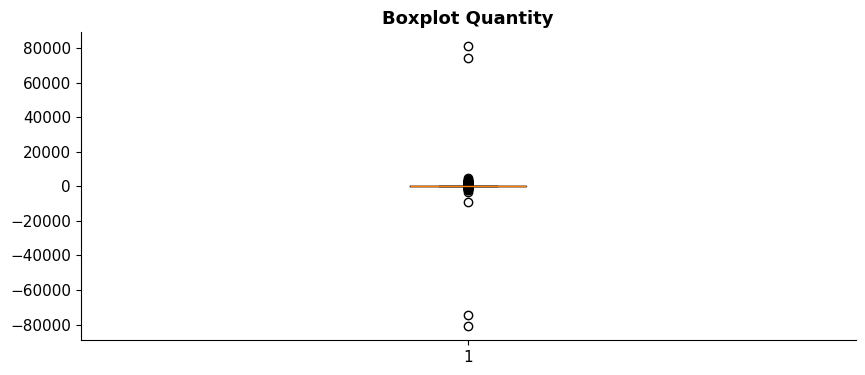

In [23]:
#Перевіримо викиди Quantity
plt.figure(figsize=(10,4))
plt.boxplot(df['Quantity'])
plt.title('Boxplot Quantity')
plt.show()

In [24]:
#Знаходимо outliers
outliers = df[
    (df['Quantity'] < -40000) |
    (df['Quantity'] > 40000)
]

print(f"Кількість викидів: {len(outliers)}")
outliers[['Quantity']].sort_values('Quantity')

Кількість викидів: 4


,Quantity
540422,-80995
61624,-74215
61619,74215
540421,80995


In [25]:
#Виведем їх для аналізу
df[df['Quantity'].isin([-80995, -74215, 74215, 80995])]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346,United Kingdom
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446,United Kingdom


Аналіз виявлених викидів показав, що вони відображають нетипову велику транзакцію та її повне повернення. Для запобігання викривленню результатів аналізу ці записи були виключені з дослідження.

In [26]:
#Виключаемо екстремальні значення Quantity
df = df[~df['Quantity'].isin([80995, -80995, 74215, -74215])]

print(f"Розмір датасету після очищення: {df.shape}")

Розмір датасету після очищення: (531205, 8)


---
##5. ⚒️Нормалізація i розподіл таблиць

Після очищення датасет складався з 531 205 транзакцій. Для побудови аналітичної моделі дані були нормалізовані та розподілені між кількома взаємопов'язаними таблицями:

- Customers — інформація про клієнтів;
- Products — довідник товарів;
- Orders — замовлення;
- OrderItems — позиції замовлень.

Нормалізація дозволила зменшити надлишковість даних, забезпечити цілісність зв'язків між сутностями та створити структуру, оптимальну для виконання SQL-запитів у BigQuery.


In [27]:
# 1. CUSTOMERS — унікальні клієнти
customers = (
    df[['CustomerID', 'Country']]
    .dropna(subset=['CustomerID'])
    .drop_duplicates(subset=['CustomerID'])
    .reset_index(drop=True)
)
customers.insert(0, 'customer_id', range(1, len(customers) + 1))

# 2. PRODUCTS — унікальні товари
products = (
    df[['StockCode', 'Description']]
    .drop_duplicates(subset=['StockCode'])
    .reset_index(drop=True)
)

# 3. ORDERS — унікальні замовлення (без позицій)
orders = (
    df[['InvoiceNo', 'InvoiceDate', 'CustomerID']]
    .drop_duplicates(subset=['InvoiceNo'])
    .reset_index(drop=True)
)

# 4. ORDER_ITEMS — позиції в замовленнях
order_items = (
    df[['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice']]
    .reset_index(drop=True)
)


# Зберігаємо
customers.to_csv("customers.csv", index=False)
products.to_csv("products.csv", index=False)
orders.to_csv("orders.csv", index=False)
order_items.to_csv("order_items.csv", index=False)

print(f"customers:   {len(customers):>5} рядків")
print(f"products:    {len(products):>5} рядків")
print(f"orders:      {len(orders):>5} рядків")
print(f"order_items: {len(order_items):>5} рядків")



customers:    4361 рядків
products:     3922 рядків
orders:      23191 рядків
order_items: 531205 рядків


In [28]:
#Завантаження у BigQuery
PROJECT_ID = "my-final-project-497412"
DATASET    = "ecommerce_data"

client = bigquery.Client(project=PROJECT_ID)

tables = {
    "customers":   pd.read_csv("customers.csv"),
    "products":    pd.read_csv("products.csv"),
    "orders":      pd.read_csv("orders.csv"),
    "order_items": pd.read_csv("order_items.csv"),
}

for name, table_df in tables.items():
    table_id = f"{PROJECT_ID}.{DATASET}.{name}"
    job = client.load_table_from_dataframe(
        table_df, table_id,
        job_config=bigquery.LoadJobConfig(write_disposition="WRITE_TRUNCATE"),
    )
    job.result()
    print(f"  ✅ {name}: {client.get_table(table_id).num_rows} рядків")


  ✅ customers: 4361 рядків
  ✅ products: 3922 рядків
  ✅ orders: 23191 рядків
  ✅ order_items: 531205 рядків


---
##6. ❓Бізнес-питання


Метою аналізу бізнес-питан є виявлення факторів, що впливають на повернення товарів, поведінку клієнтів, рівень утримання та ефективність продажів.



### 6.1 Які товари мають найвищий відсоток повернень?

In [29]:
query = f"""
SELECT
    p.StockCode,
    p.Description,
    SUM(CASE WHEN oi.Quantity > 0 THEN oi.Quantity ELSE 0 END) AS sold_qty,
    ABS(SUM(CASE WHEN oi.Quantity < 0 THEN oi.Quantity ELSE 0 END)) AS returned_qty,
    ROUND(
        ABS(SUM(CASE WHEN oi.Quantity < 0 THEN oi.Quantity ELSE 0 END))
        / SUM(CASE WHEN oi.Quantity > 0 THEN oi.Quantity ELSE 0 END) * 100,
        2
    ) AS return_rate_pct
FROM {full_table_name('order_items')} oi
JOIN {full_table_name('products')} p
    ON oi.StockCode = p.StockCode
GROUP BY p.StockCode, p.Description
HAVING sold_qty >= 50
ORDER BY return_rate_pct DESC
LIMIT 10
"""
run_query(query)

,StockCode,Description,sold_qty,returned_qty,return_rate_pct
0,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,9461,9376,99.10
1,85232B,SET OF 3 BABUSHKA STACKING TINS,274,255,93.07
2,23113,PANTRY CHOPPING BOARD,1154,946,81.98
3,85023B,EAU DE NILE JEWELLED PHOTOFRAME,105,73,69.52
4,23055,IVORY CHANDELIER T-LIGHT HOLDER,657,432,65.75
5,23056,FLOWERS CHANDELIER T-LIGHT HOLDER,963,579,60.12
6,47566B,TEA TIME PARTY BUNTING,2379,1424,59.86
7,23057,GEMSTONE CHANDELIER T-LIGHT HOLDER,773,433,56.02
8,47351B,BLUE VOILE LAMPSHADE,86,48,55.81
9,22920,HERB MARKER BASIL,3423,1527,44.61


### 📌 Insight

Аналіз показав, що окремі товари мають критично високий рівень повернень (до 99%). Найбільша частка повернень спостерігається серед декоративних товарів для дому та свічників. Це може свідчити про проблеми з якістю продукції, пакуванням або невідповідність очікуванням покупців.

### ✅ Recommendation


Рекомендується провести додатковий аналіз причин повернень, перевірити відгуки покупців та оцінити якість логістичних процесів. Та переглянути підхід до закупівлі й представлення цих товарів клієнтам.

Товар ROTATING SILVER ANGELS T-LIGHT HLDR має повернення: 99.1%
Перевіремо цей товар

In [30]:
query = f"""
SELECT *
FROM {full_table_name('order_items')}
WHERE StockCode = '84347'

"""
run_query(query)

,InvoiceNo,StockCode,Quantity,UnitPrice
0,C536757,84347,-9360,0.03
1,C537251,84347,-9,2.55
2,C540164,84347,-6,2.55
3,C572473,84347,-1,2.55
4,536488,84347,1,2.55
...,...,...,...,...
463,536784,84347,240,1.88
464,538191,84347,240,1.88
465,538998,84347,480,1.88
466,572325,84347,600,1.74


Високий рівень повернень товару ROTATING SILVER ANGELS T-LIGHT HLDR обумовлений переважно однією великою транзакцією повернення на 9360 одиниць товару. Це свідчить про можливу разову бізнес-подію (повернення партії товару, скасування великого замовлення або коригування обліку), а не про систематичну проблему з товаром.

❗️Доцільно перевірити обставини повернення замовлення C536757 та оцінити його вплив на загальні показники повернень.

###6.2 Чи впливає країна клієнта на рівень повернення?

In [31]:
query = f"""
SELECT
    c.Country,
    COUNT(CASE WHEN oi.Quantity > 0 THEN 1 END) AS sales_lines,
    COUNT(CASE WHEN oi.Quantity < 0 THEN 1 END) AS return_lines,
    ROUND(
        COUNT(CASE WHEN oi.Quantity < 0 THEN 1 END)
        * 100.0 /
        COUNT(CASE WHEN oi.Quantity > 0 THEN 1 END),
        2
    ) AS return_rate_pct
FROM {full_table_name('customers')} c
JOIN {full_table_name('orders')} o
    ON c.CustomerID = o.CustomerID
JOIN {full_table_name('order_items')} oi
    ON o.InvoiceNo = oi.InvoiceNo
GROUP BY c.Country
HAVING sales_lines > 100
ORDER BY return_rate_pct DESC
"""
country_returns = run_query(query)
country_returns

,Country,sales_lines,return_lines,return_rate_pct
0,USA,179,112,62.57
1,Malta,109,14,12.84
2,Japan,321,34,10.59
3,Australia,1249,73,5.84
4,Italy,741,42,5.67
5,Germany,8643,437,5.06
6,EIRE,7126,242,3.40
7,Poland,325,11,3.38
8,Sweden,427,9,2.11
9,Denmark,382,8,2.09


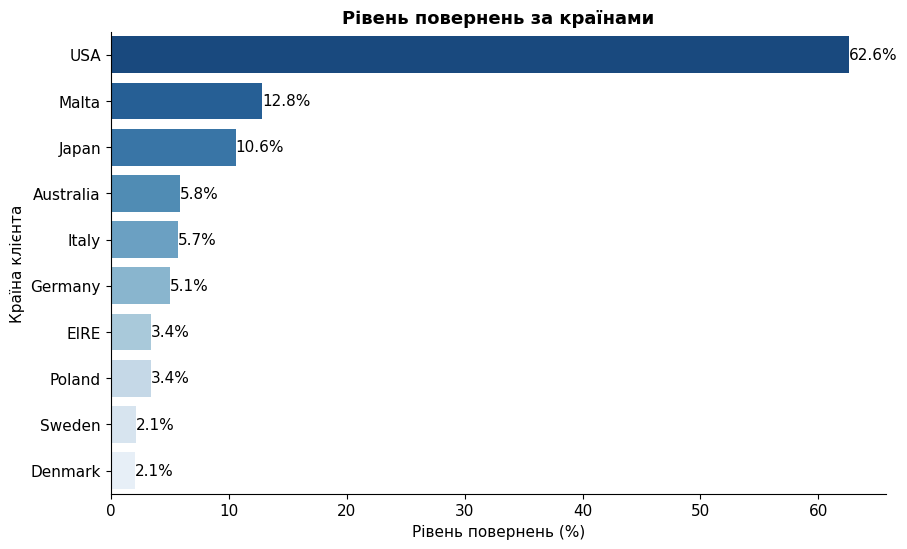

In [32]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=country_returns.head(10),
    palette='Blues_r',
    x='return_rate_pct',
    y='Country'
)

for i in ax.containers:
    ax.bar_label(i, fmt='%.1f%%')

plt.title('Рівень повернень за країнами')
plt.xlabel('Рівень повернень (%)')
plt.ylabel('Країна клієнта')

plt.show()

### 📌 Insight
Аналіз показав, що рівень повернень суттєво відрізняється між країнами. Найвищий показник спостерігається у США, що значно перевищує показники інших країн. Але так як продажів було дуже мало - 179, то 62% може бути наслідком малого обсягу даних, а не реальною бізнес-проблемою. Це може свідчити про специфічні проблеми з логістикою, очікуваннями клієнтів або особливостями асортименту на цьому ринку.

### ✅ Recommendation
Доцільно провести додатковий аналіз повернень у США: визначити товари, які повертаються найчастіше, перевірити терміни доставки та оцінити якість обслуговування клієнтів на цьому ринку.

###6.3 Скільки часу проходить між першою та другою покупкою клієнта?

In [33]:
query = f"""
WITH customer_orders AS (
    SELECT
        CAST(CustomerID AS INT64) AS CustomerID,
        DATE(InvoiceDate) AS order_date
    FROM {full_table_name('orders')}
    WHERE CustomerID IS NOT NULL
),

ranked_orders AS (
    SELECT
        CustomerID,
        order_date,
        ROW_NUMBER() OVER (
            PARTITION BY CustomerID
            ORDER BY order_date
        ) AS order_num
    FROM customer_orders
),

first_second_orders AS (
    SELECT
        CustomerID,
        MAX(IF(order_num = 1, order_date, NULL)) AS first_order,
        MAX(IF(order_num = 2, order_date, NULL)) AS second_order
    FROM ranked_orders
    GROUP BY CustomerID
)

SELECT
    CustomerID,
    DATE_DIFF(second_order, first_order, DAY) AS days_between
FROM first_second_orders
WHERE second_order IS NOT NULL
"""

df_repeat_purchase = run_query(query)
df_repeat_purchase['days_between'].describe()

,days_between
count,3033.0
mean,63.533136
std,75.04578
min,0.0
25%,8.0
50%,35.0
75%,95.0
max,366.0


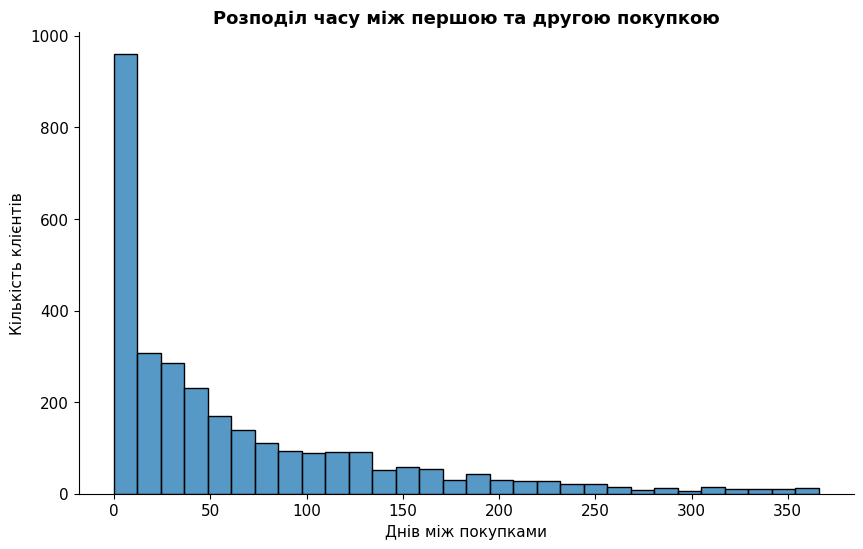

In [34]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df_repeat_purchase,
    x='days_between',
    bins=30
)

plt.title('Розподіл часу між першою та другою покупкою')
plt.xlabel('Днів між покупками')
plt.ylabel('Кількість клієнтів')

plt.show()

### 📌 Insight
Більшість клієнтів здійснюють повторну покупку протягом перших 30 днів після першого замовлення. З часом кількість повторних покупок поступово знижується.

### ✅ Recommendation

Надсилати персональні пропозиції через 7–14 днів після першої покупки.
Стимулювати другу покупку бонусами або промокодами в перший місяць.
Запускати кампанії реактивації для клієнтів, які не купували понад 60–90 днів.

###6.4 Які категорії товарів генерують найбільну виручку?


In [35]:
query = f"""
SELECT
    p.Description,
    ROUND(SUM(oi.Quantity * oi.UnitPrice), 2) AS revenue
FROM {full_table_name('order_items')} oi
JOIN {full_table_name('products')} p
    ON oi.StockCode = p.StockCode
WHERE oi.Quantity > 0
GROUP BY p.Description
ORDER BY revenue DESC
LIMIT 10
"""
top_products = run_query(query)
top_products

,Description,revenue
0,REGENCY CAKESTAND 3 TIER,174156.54
1,WHITE HANGING HEART T-LIGHT HOLDER,106415.23
2,PARTY BUNTING,99445.23
3,JUMBO BAG RED RETROSPOT,94159.81
4,RABBIT NIGHT LIGHT,66870.03
5,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59
6,ASSORTED COLOUR BIRD ORNAMENT,58927.62
7,CHILLI LIGHTS,54096.36
8,PICNIC BASKET WICKER SMALL,51408.77
9,SMALL POPCORN HOLDER,51334.47


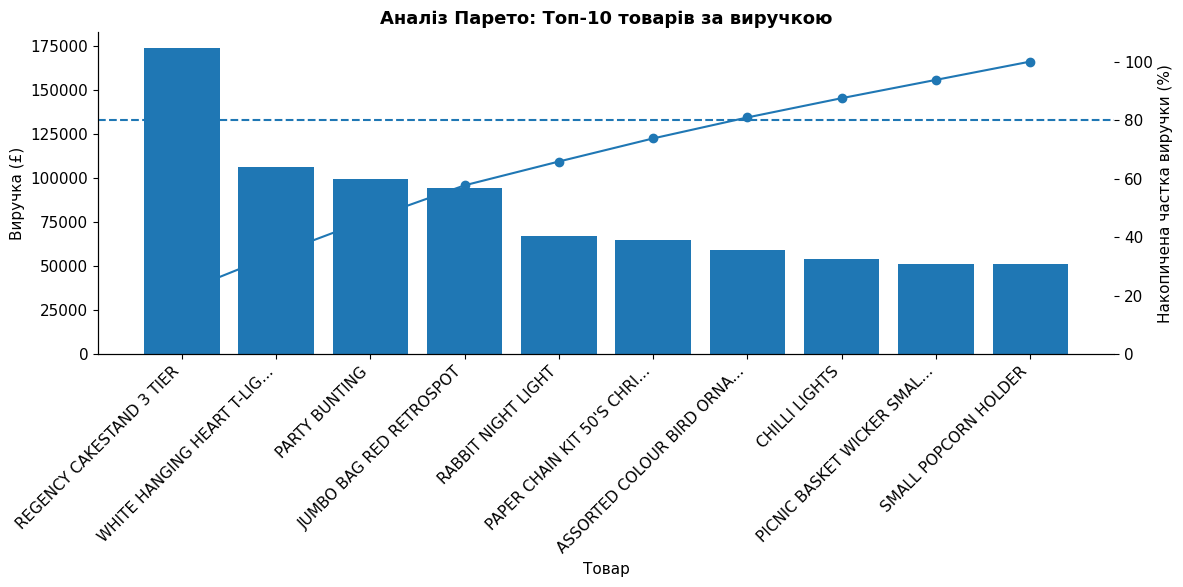

In [36]:
# Підготовка даних для Pareto Chart
pareto = top_products.sort_values('revenue', ascending=False).copy()

# Скорочуємо довгі назви товарів
pareto['short_name'] = pareto['Description'].apply(
    lambda x: x[:25] + '...' if len(x) > 25 else x
)

# Накопичена частка виручки
pareto['cum_pct'] = (
    pareto['revenue'].cumsum()
    / pareto['revenue'].sum() * 100
)

fig, ax1 = plt.subplots(figsize=(12,6))

# Стовпчики
ax1.bar(
    pareto['short_name'],
    pareto['revenue']
)

ax1.set_ylabel('Виручка (£)')
ax1.set_xlabel('Товар')
plt.xticks(rotation=45, ha='right')

# Лінія накопиченої частки
ax2 = ax1.twinx()

ax2.plot(
    pareto['short_name'],
    pareto['cum_pct'],
    marker='o'
)

ax2.set_ylabel('Накопичена частка виручки (%)')
ax2.set_ylim(0, 110)

# Лінія 80%
ax2.axhline(y=80, linestyle='--')

plt.title('Аналіз Парето: Топ-10 товарів за виручкою')
plt.tight_layout()
plt.show()

📌 Insight

Аналіз за принципом Парето показав, що перші 7 із 10 найбільш прибуткових товарів формують понад 80% виручки серед топ-10 товарів. Найбільший внесок робить товар REGENCY CAKESTAND 3 TIER, який суттєво випереджає інші позиції за обсягом доходу. Це свідчить про високу концентрацію виручки на обмеженій кількості товарів.

✅ Recommendation

Компанії доцільно приділити особливу увагу товарам-лідерам: контролювати їхню наявність на складі, підтримувати стабільну якість та використовувати їх у маркетингових кампаніях. Також варто дослідити можливості збільшення продажів товарів із другої половини рейтингу для зменшення залежності від кількох ключових позицій.

###6.5 Чи змінюється виручка по місяцям? Чи є сезон?


In [37]:
query = f"""
SELECT
    FORMAT_DATE('%Y-%m', DATE(o.InvoiceDate)) AS month,
    ROUND(SUM(oi.Quantity * oi.UnitPrice), 2) AS revenue
FROM {full_table_name('orders')} o
JOIN {full_table_name('order_items')} oi
    ON o.InvoiceNo = oi.InvoiceNo
WHERE oi.Quantity > 0
GROUP BY month
ORDER BY month
"""
monthly_revenue = run_query(query)
monthly_revenue

,month,revenue
0,2010-12,775640.91
1,2011-01,593196.64
2,2011-02,507799.87
3,2011-03,689833.51
4,2011-04,515377.99
5,2011-05,739953.00
6,2011-06,737558.98
7,2011-07,688219.34
8,2011-08,724216.50
9,2011-09,1028320.38


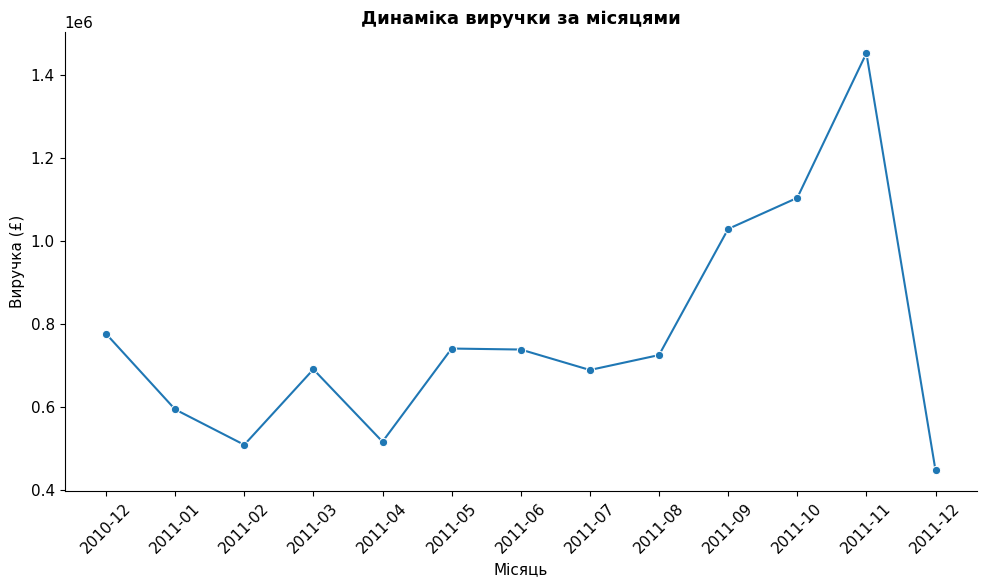

In [38]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=monthly_revenue,
    x='month',
    y='revenue',
    marker='o'
)

plt.title('Динаміка виручки за місяцями')
plt.xlabel('Місяць')
plt.ylabel('Виручка (£)')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📌 Insight
Виручка компанії має сезонний характер. Найбільше зростання спостерігається з вересня по листопад 2011 року, а пік продажів припадає на листопад.

Різке падіння в грудні 2011 року не варто інтерпретувати як зниження попиту, оскільки дані за грудень є неповними (містять лише перші дні місяця).

### ✅ Recommendation
Доцільно збільшувати маркетингову активність і запаси товарів напередодні святкового сезону, коли попит є найвищим.

###6.6 Який середній чек?


In [39]:
query = f"""
WITH order_totals AS (
    SELECT
        InvoiceNo,
        SUM(Quantity * UnitPrice) AS order_value
    FROM {full_table_name('order_items')}
    WHERE Quantity > 0
    GROUP BY InvoiceNo
)

SELECT
    ROUND(AVG(order_value), 2) AS avg_order_value
FROM order_totals
"""
run_query(query)

,avg_order_value
0,505.87


### 📌 Insight
Середній чек становить 505.87, що свідчить про відносно високу вартість одного замовлення. Це може означати, що клієнти часто купують кілька товарів одночасно або обирають товари з вищою ціною.

### ✅ Recommendation
Для подальшого збільшення виручки компанії варто використовувати рекомендації супутніх товарів та акційні набори, щоб стимулювати клієнтів збільшувати суму замовлення.


###6.7 Які товари купують частіше?

In [40]:
query = f"""
SELECT
    p.Description,
    SUM(oi.Quantity) AS total_quantity
FROM {full_table_name('order_items')} oi
JOIN {full_table_name('products')} p
    ON oi.StockCode = p.StockCode
WHERE oi.Quantity > 0
GROUP BY p.Description
ORDER BY total_quantity DESC
LIMIT 10
"""
top_products_qty = run_query(query)
top_products_qty

,Description,total_quantity
0,SMALL POPCORN HOLDER,56898
1,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951
2,JUMBO BAG RED RETROSPOT,48371
3,WHITE HANGING HEART T-LIGHT HOLDER,37933
4,PACK OF 72 RETROSPOT CAKE CASES,36396
5,ASSORTED COLOUR BIRD ORNAMENT,36362
6,RABBIT NIGHT LIGHT,30739
7,MINI PAINT SET VINTAGE,26633
8,PACK OF 12 LONDON TISSUES,26119
9,PACK OF 60 PINK PAISLEY CAKE CASES,24820


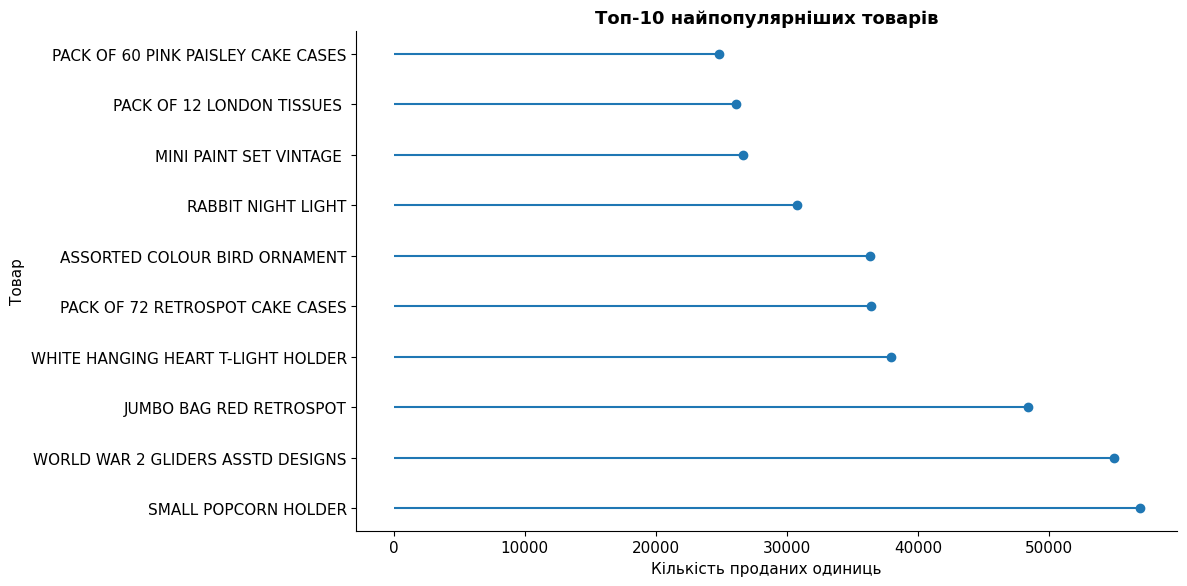

In [41]:
plt.figure(figsize=(12,6))

plt.hlines(
    y= top_products_qty ['Description'],
    xmin=0,
    xmax=top_products_qty ['total_quantity']
)

plt.plot(
    top_products_qty['total_quantity'],
    top_products_qty['Description'],
    'o'
)

plt.xlabel('Кількість проданих одиниць')
plt.ylabel('Товар')
plt.title('Топ-10 найпопулярніших товарів')

plt.tight_layout()
plt.show()

### 📌 Insight
Найчастіше клієнти купують SMALL POPCORN HOLDER, WORLD WAR 2 GLIDERS ASSTD DESIGNS та JUMBO BAG RED RETROSPOT. Популярність товару не завжди означає високу виручку, оскільки частина таких товарів має невисоку ціну.

### ✅ Recommendation
Варто підтримувати наявність найпопулярніших товарів на складі та використовувати їх для стимулювання додаткових продажів через рекомендації супутніх товарів.

###6.8 Які товари найчастіше купують разом?

In [42]:
query = f"""
WITH pairs AS (
    SELECT
        a.StockCode AS product_1,
        b.StockCode AS product_2,
        COUNT(DISTINCT a.InvoiceNo) AS pair_count
    FROM {full_table_name('order_items')} a
    JOIN {full_table_name('order_items')} b
        ON a.InvoiceNo = b.InvoiceNo
        AND a.StockCode < b.StockCode
    WHERE a.Quantity > 0
      AND b.Quantity > 0
    GROUP BY product_1, product_2
)

SELECT
    p1.Description AS product_1,
    p2.Description AS product_2,
    pair_count
FROM pairs
JOIN `{PROJECT_ID}.{DATASET}.products` p1
    ON pairs.product_1 = p1.StockCode
JOIN `{PROJECT_ID}.{DATASET}.products` p2
    ON pairs.product_2 = p2.StockCode
ORDER BY pair_count DESC
LIMIT 5
"""
top_pairs = run_query(query)
top_pairs

,product_1,product_2,pair_count
0,JUMBO BAG PINK POLKADOT,JUMBO BAG RED RETROSPOT,825
1,GREEN REGENCY TEACUP AND SAUCER,ROSES REGENCY TEACUP AND SAUCER,767
2,JUMBO STORAGE BAG SUKI,JUMBO BAG RED RETROSPOT,724
3,JUMBO SHOPPER VINTAGE RED PAISLEY,JUMBO BAG RED RETROSPOT,680
4,LUNCH BAG RED RETROSPOT,LUNCH BAG SUKI DESIGN,655


### 📌 Insight
Клієнти часто купують разом товари однієї серії, зокрема JUMBO BAG, LUNCH BAG та REGENCY TEACUP. Найчастіше в парах зустрічається JUMBO BAG RED RETROSPOT.

### ✅ Recommendation
Варто використовувати ці товарні пари для рекомендацій та створення акційних наборів, щоб збільшити середній чек.

###6.9 Який рівень утримання клієнтів по когортах?


In [43]:
query = f"""
WITH cohort_data AS (

    SELECT
        CustomerID,
        DATE_TRUNC(DATE(MIN(InvoiceDate)), MONTH) AS cohort_month
    FROM `{PROJECT_ID}.{DATASET}.orders`
    GROUP BY CustomerID

),

customer_activity AS (

    SELECT
        o.CustomerID,
        DATE_TRUNC(DATE(o.InvoiceDate), MONTH) AS activity_month
    FROM `{PROJECT_ID}.{DATASET}.orders` o
    GROUP BY o.CustomerID, activity_month

),

retention AS (

    SELECT
        c.cohort_month,
        a.activity_month,

        DATE_DIFF(
            a.activity_month,
            c.cohort_month,
            MONTH
        ) AS cohort_index,

        COUNT(DISTINCT a.CustomerID) AS active_customers

    FROM cohort_data c
    JOIN customer_activity a
        ON c.CustomerID = a.CustomerID

    GROUP BY
        cohort_month,
        activity_month,
        cohort_index

),

cohort_size AS (

    SELECT
        cohort_month,
        COUNT(DISTINCT CustomerID) AS cohort_size
    FROM cohort_data
    GROUP BY cohort_month

)

SELECT
    r.cohort_month,
    r.cohort_index,
    ROUND(
        r.active_customers * 100.0 / c.cohort_size,
        2
    ) AS retention_rate

FROM retention r
JOIN cohort_size c
    ON r.cohort_month = c.cohort_month

ORDER BY
    cohort_month,
    cohort_index
"""
retention_df = client.query(query).to_dataframe()

retention_df.head()

,cohort_month,cohort_index,retention_rate
0,2010-12-01,0,100.00
1,2010-12-01,1,38.01
2,2010-12-01,2,33.05
3,2010-12-01,3,38.65
4,2010-12-01,4,35.90


In [44]:
cohort_pivot = retention_df.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='retention_rate'
)

cohort_pivot

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12
cohort_month,,,,,,,,,,,,,
2010-12-01,100.0,38.01,33.05,38.65,35.90,39.70,37.80,35.16,35.27,39.39,37.28,49.95,27.35
2011-01-01,100.0,23.87,28.40,24.34,32.46,30.07,26.25,25.54,30.79,34.61,36.99,15.04,NaN
2011-02-01,100.0,24.60,19.31,28.31,26.98,24.60,25.93,27.78,25.93,31.48,9.26,NaN,NaN
2011-03-01,100.0,18.91,25.28,21.87,22.78,17.77,26.20,23.69,28.70,8.88,NaN,NaN,NaN
2011-04-01,100.0,22.48,22.15,21.14,20.81,23.83,22.82,26.17,8.39,NaN,NaN,NaN,NaN
2011-05-01,100.0,23.66,17.20,17.20,21.51,24.37,26.52,10.04,NaN,NaN,NaN,NaN,NaN
2011-06-01,100.0,20.85,18.30,27.23,24.68,33.19,10.21,NaN,NaN,NaN,NaN,NaN,NaN
2011-07-01,100.0,21.51,20.43,23.66,27.96,11.83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08-01,100.0,24.55,24.55,25.15,13.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


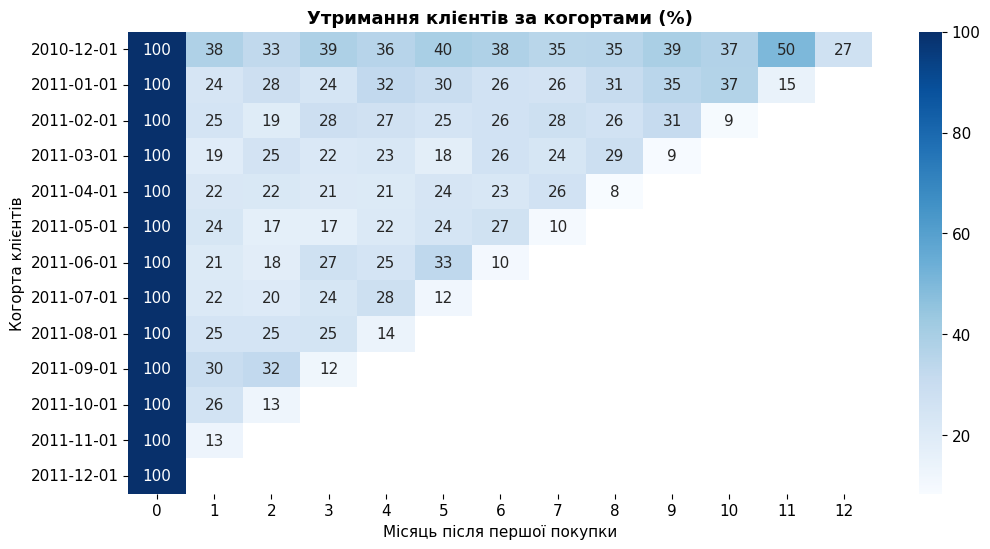

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.heatmap(
    cohort_pivot,
    annot=True,
    fmt='.0f',
    cmap='Blues'
)

plt.title('Утримання клієнтів за когортами (%)')
plt.xlabel('Місяць після першої покупки')
plt.ylabel('Когорта клієнтів')

plt.show()

###📌 Insight
У всіх когортах спостерігається зниження рівня утримання після першої покупки. Найбільший відтік відбувається вже в перший місяць, коли повертається лише 20–40% клієнтів. Водночас когорта грудня 2010 року демонструє найкраще довгострокове утримання, що свідчить про вищу лояльність залучених у святковий період клієнтів.

###✅ Recommendation
Компанії варто зосередитися на утриманні клієнтів у перші місяці після покупки через персоналізовані пропозиції, програми лояльності та email-кампанії, оскільки саме в цей період відбувається найбільша втрата клієнтів.

###6.10 RFM аналіз - сегментація клієнтів за їхньою поведінкою

In [46]:
df.head(2)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [47]:
df_customer = df[df['CustomerID'].notna()]
df_customer.shape

(399655, 8)

In [48]:
#Додаєм колонку Revenue та знаходимо останню дату в датасеті - дата зрізу даних
df_customer['Revenue'] = df['Quantity'] * df['UnitPrice']
last_date_df = df['InvoiceDate'].max() + pd.Timedelta(days=1) #ocтання дата в датасети
last_date_df

Timestamp('2011-12-10 12:50:00')

In [49]:
rfm = df_customer.groupby('CustomerID').agg({
    #різниця у днях від дати останньої покупки
    'InvoiceDate': lambda x: (last_date_df - x.max()).days,
    #всього покупок
    'InvoiceNo': 'nunique',
    #cума яку витратив покупець
    'Revenue': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347,2,7,4310.00
12348,75,4,1437.24
12349,19,1,1457.55
12350,310,1,294.40
12352,36,8,1265.41


In [50]:
#Перетворюєм отриманні значення у оцінки
rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])
rfm.head()

,Recency,Frequency,Monetary,R,F,M
CustomerID,,,,,,
12347,2,7,4310.00,4,4,4
12348,75,4,1437.24,2,3,3
12349,19,1,1457.55,3,1,3
12350,310,1,294.40,1,1,2
12352,36,8,1265.41,3,4,3


In [51]:
#Сегментуємо покупців
def segment(row):
    if row['R'] >= 4 and row['F'] >= 4 and row['M'] >= 4:
        return 'Champions'
    elif row['R'] >= 3 and row['F'] >= 3:
        return 'Loyal'
    elif row['R'] >= 4 and row['F'] <= 2:
        return 'New Customers'
    elif row['R'] <= 2 and row['F'] >= 3:
        return 'At Risk'
    elif row['R'] <= 2 and row['F'] <= 2:
        return 'Lost'
    else:
        return 'Promising'

rfm['Segment'] = rfm.apply(segment, axis=1)
rfm.head()

,Recency,Frequency,Monetary,R,F,M,Segment
CustomerID,,,,,,,
12347,2,7,4310.00,4,4,4,Champions
12348,75,4,1437.24,2,3,3,At Risk
12349,19,1,1457.55,3,1,3,Promising
12350,310,1,294.40,1,1,2,Lost
12352,36,8,1265.41,3,4,3,Loyal


In [52]:
#Дивимось розподіл клієнтів
rfm['Segment'].value_counts()

,count
Segment,
Lost,1510
Loyal,1031
At Risk,653
Champions,496
Promising,434
New Customers,237


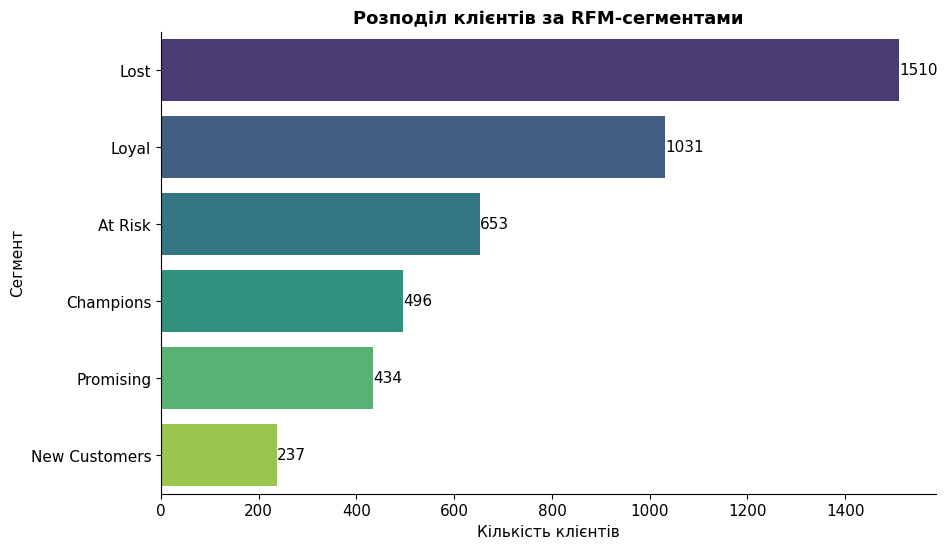

In [53]:
plt.figure(figsize=(10,6))

segment_counts = rfm['Segment'].value_counts()

ax = sns.barplot(
    x=segment_counts.values,
    y=segment_counts.index,
    hue=segment_counts.index,
    palette='viridis',
    legend=False
)

plt.title('Розподіл клієнтів за RFM-сегментами')
plt.xlabel('Кількість клієнтів')
plt.ylabel('Сегмент')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

Найбільшу частку клієнтів становить сегмент Lost, що свідчить про значний відтік клієнтів. Водночас компанія має велику базу Loyal клієнтів та майже 500 Champions, які є найбільш цінними для бізнесу.
### ✅ Recommendation
**Lost** - втрачені (давно зникли, рідко купували)
Реактувати складно, але спробувати варто - агресивні знижки

**Loyal** - активні постійні клієнти
Програми лояльності, знижки, персоналізовані пропозиції.

**At Risk** - давно не купували, але були частими
Персональна знижка на основі попередніх замовлень.

**Champions** - купували нещодавно, часто, багато (найцінніші)
Програми лояльності, ексклюзивні пропозиції, ранній доступ до новинок.

**Promising** - перспективні, недавно зробили покупку, але поки що купують нечасто
Знижка на другу покупку, email / push після першого замовлення, персональні рекомендації.

**New Customers** - нещодавно, але мало (потенційно ціні)
Welcom-cесія, Знижка на другу покупку, інформація про гарантії і повернення

###6.11 Які RFM-сегменти генерують найбільшу частку виручки компанії?

In [54]:
segment_revenue = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

segment_revenue

,Segment,Monetary
0,Champions,4329180.820
1,Loyal,2019356.381
2,At Risk,967242.851
3,Lost,633972.451
4,Promising,191807.960
5,New Customers,123916.470



### 📌 Insight

Сегмент Champions генерує найбільшу виручку (£4,33 млн), що більш ніж удвічі перевищує виручку сегмента Loyal (£2,02 млн). Незважаючи на меншу кількість клієнтів, саме Champions є найціннішими для бізнесу та формують основну частину доходу.

### ✅ Recommendation

Компанії варто зосередитися на утриманні сегментів Champions та Loyal через програми лояльності, персоналізовані пропозиції та ексклюзивні акції, оскільки саме вони забезпечують найбільшу частку виручки.

In [55]:
segment_revenue = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

segment_revenue

,Segment,Monetary
0,Champions,4329180.820
1,Loyal,2019356.381
2,At Risk,967242.851
3,Lost,633972.451
4,Promising,191807.960
5,New Customers,123916.470


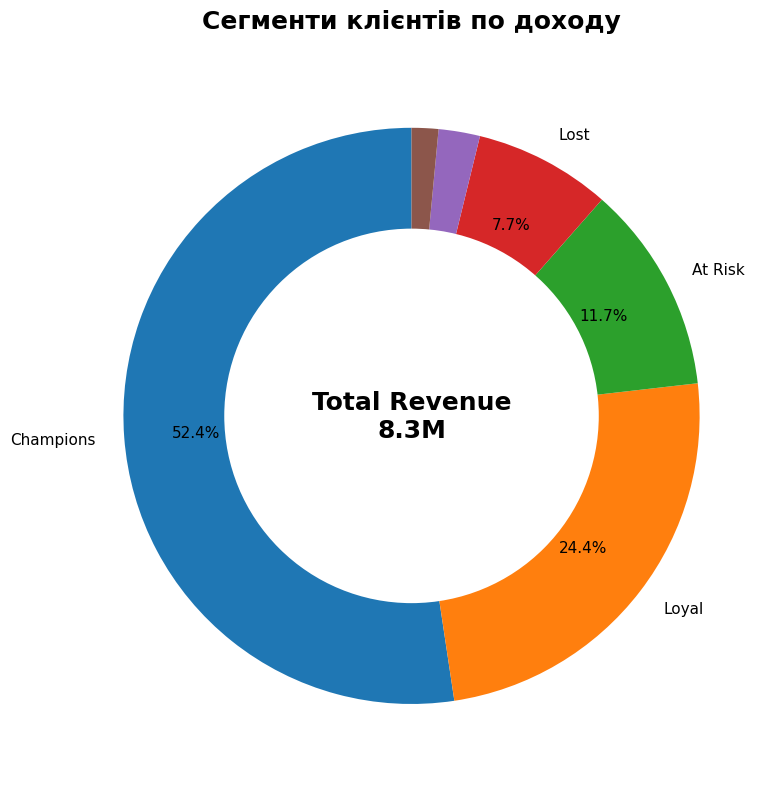

In [56]:
# Виручка за сегментами
revenue_by_segment = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

# Частка виручки
revenue_share = revenue_by_segment / revenue_by_segment.sum()

plt.figure(figsize=(10, 8))

wedges, texts, autotexts = plt.pie(
    revenue_by_segment,
    labels=[
        segment if share > 0.03 else ''
        for segment, share in zip(revenue_by_segment.index, revenue_share)
    ],
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    startangle=90,
    pctdistance=0.75
)

# Створюємо отвір посередині
centre_circle = plt.Circle((0, 0), 0.65, fc='white')
plt.gca().add_artist(centre_circle)

# Загальна виручка в центрі
total_revenue = revenue_by_segment.sum()

plt.text(
    0, 0,
    f'Total Revenue\n{total_revenue/1_000_000:.1f}M',
    ha='center',
    va='center',
    fontsize=18,
    fontweight='bold'
)

plt.title(
    'Cегменти клієнтів по доходу',
    fontsize=18,
    pad=20
)

plt.tight_layout()
plt.show()

### 📌 Insight

Сегменти Champions (52,4%) та Loyal (24,4%) разом генерують 76,8% усієї виручки. Незважаючи на меншу кількість клієнтів, саме Champions є найціннішими для бізнесу та формують основну частину доходу. Водночас сегмент At Risk формує майже 12% доходу, що свідчить про значний потенціал для кампаній з утримання клієнтів.

### ✅ Recommendation

Компанії варто зосередитися на утриманні сегментів Champions та Loyal через програми лояльності, персоналізовані пропозиції та ексклюзивні акції, оскільки саме вони забезпечують найбільшу частку виручки. Також необхідно реактивація тих, хто починає втрачати інтерес до покупок.


---
##📌 Фінальний висновок
Проведений аналіз дозволив виявити товари та країни з підвищеним рівнем повернень, що допоможе зменшити втрати від повернень та оптимізувати операційні витрати.

**Когортний аналіз** показав зниження утримання клієнтів після першої покупки, а **RFM-сегментація** дозволила визначити найбільш цінні сегменти клієнтів (Champions та Loyal) і клієнтів із ризиком відтоку (At Risk).

Аналіз продажів виявив сезонність попиту, ключові товари, що формують основну частину виручки, а також популярні товарні комбінації для рекомендаційної системи.

---

##📈 Бізнес-результат
- Виявлено товари та країни з підвищеним рівнем повернень, що створює можливості для зниження операційних витрат.
- Визначено найбільш цінні сегменти клієнтів (**Champions** та **Loyal**) для ефективнішого розподілу маркетингового бюджету.
- Виявлено сегмент **At Risk** для запуску кампаній з реактивації клієнтів.
- Знайдено популярні товарні комбінації для покращення рекомендаційної системи та збільшення середнього чека.
- Визначено сезонні піки попиту для кращого планування запасів та маркетингових активностей.

---

##💡 Рекомендації

✅ Зменшення кількості повернень за рахунок виявлення проблемних товарів.

✅ Покращення утримання клієнтів через роботу з сегментами At Risk та New Customers.

✅ Оптимізація маркетингових кампаній завдяки фокусуванню на сегментах Champions і Loyal.

✅ Підвищення ефективності рекомендацій товарів через використання результатів Market Basket Analysis.

✅ Збільшення виручки та прибутковості бізнесу завдяки персоналізованим маркетинговим стратегіям і кращому розумінню поведінки клієнтів.